# Data Preprocessing & Feature Engineering
### Student Academic Risk Prediction — UCI "Predict Students' Dropout and Academic Success"

This notebook implements the preprocessing and feature-engineering strategy step by step:
load & profile → clean → engineer features → encode → scale → select features → assemble into a single reusable pipeline.


**Week - 2**

## 0. Setup

In [1]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

## 1. Load and Profile the Data

In [3]:
df = pd.read_csv('data.csv', sep=';')
df.columns = [c.strip() for c in df.columns]

print(df.shape)
df.head()

(4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [5]:
missing_rate = df.isna().mean().sort_values(ascending=False)
print('Total missing cells:', df.isna().sum().sum())
missing_rate.head(10)

Total missing cells: 0


,0
Marital status,0.0
Application mode,0.0
Application order,0.0
Course,0.0
Daytime/evening attendance,0.0
Previous qualification,0.0
Previous qualification (grade),0.0
Nacionality,0.0
Mother's qualification,0.0
Father's qualification,0.0


In [6]:
dupes = df.duplicated().sum()
print(f'Exact duplicate rows: {dupes}')
df = df.drop_duplicates().reset_index(drop=True)

Exact duplicate rows: 0


Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64


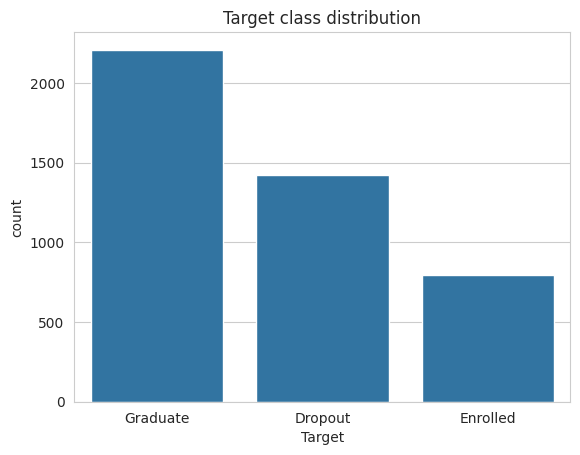

In [7]:
target_dist = df['Target'].value_counts(normalize=True).round(3)
print(target_dist)
sns.countplot(x='Target', data=df, order=df['Target'].value_counts().index)
plt.title('Target class distribution')
plt.show()

In [8]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.18,0.61,1.00,1.00,1.00,1.00,6.00
Application mode,4424.0,18.67,17.48,1.00,1.00,17.00,39.00,57.00
Application order,4424.0,1.73,1.31,0.00,1.00,1.00,2.00,9.00
Course,4424.0,8856.64,2063.57,33.00,9085.00,9238.00,9556.00,9991.00
Daytime/evening attendance,4424.0,0.89,0.31,0.00,1.00,1.00,1.00,1.00
Previous qualification,4424.0,4.58,10.22,1.00,1.00,1.00,1.00,43.00
Previous qualification (grade),4424.0,132.61,13.19,95.00,125.00,133.10,140.00,190.00
Nacionality,4424.0,1.87,6.91,1.00,1.00,1.00,1.00,109.00
Mother's qualification,4424.0,19.56,15.60,1.00,2.00,19.00,37.00,44.00
Father's qualification,4424.0,22.28,15.34,1.00,3.00,19.00,37.00,44.00


## 1.3 Descriptive Visualization

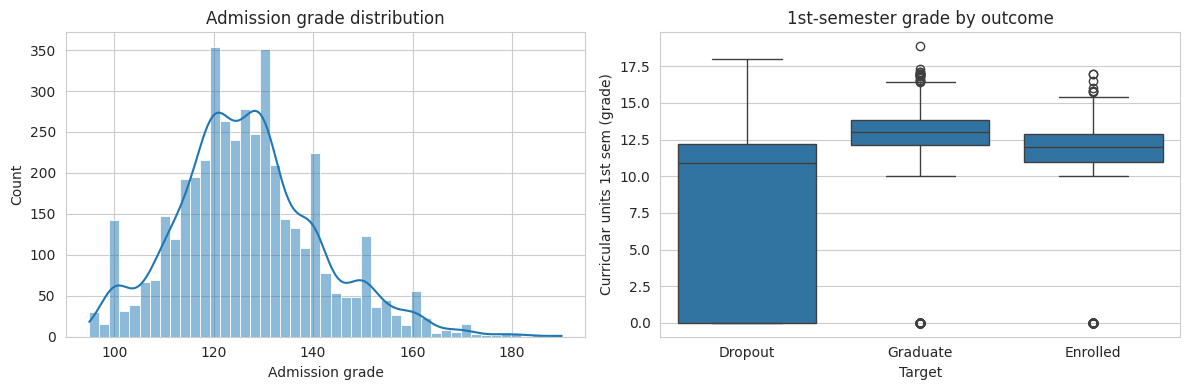

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Admission grade'], kde=True, ax=axes[0])
axes[0].set_title('Admission grade distribution')

sns.boxplot(x='Target', y='Curricular units 1st sem (grade)', data=df, ax=axes[1])
axes[1].set_title('1st-semester grade by outcome')
plt.tight_layout()
plt.show()

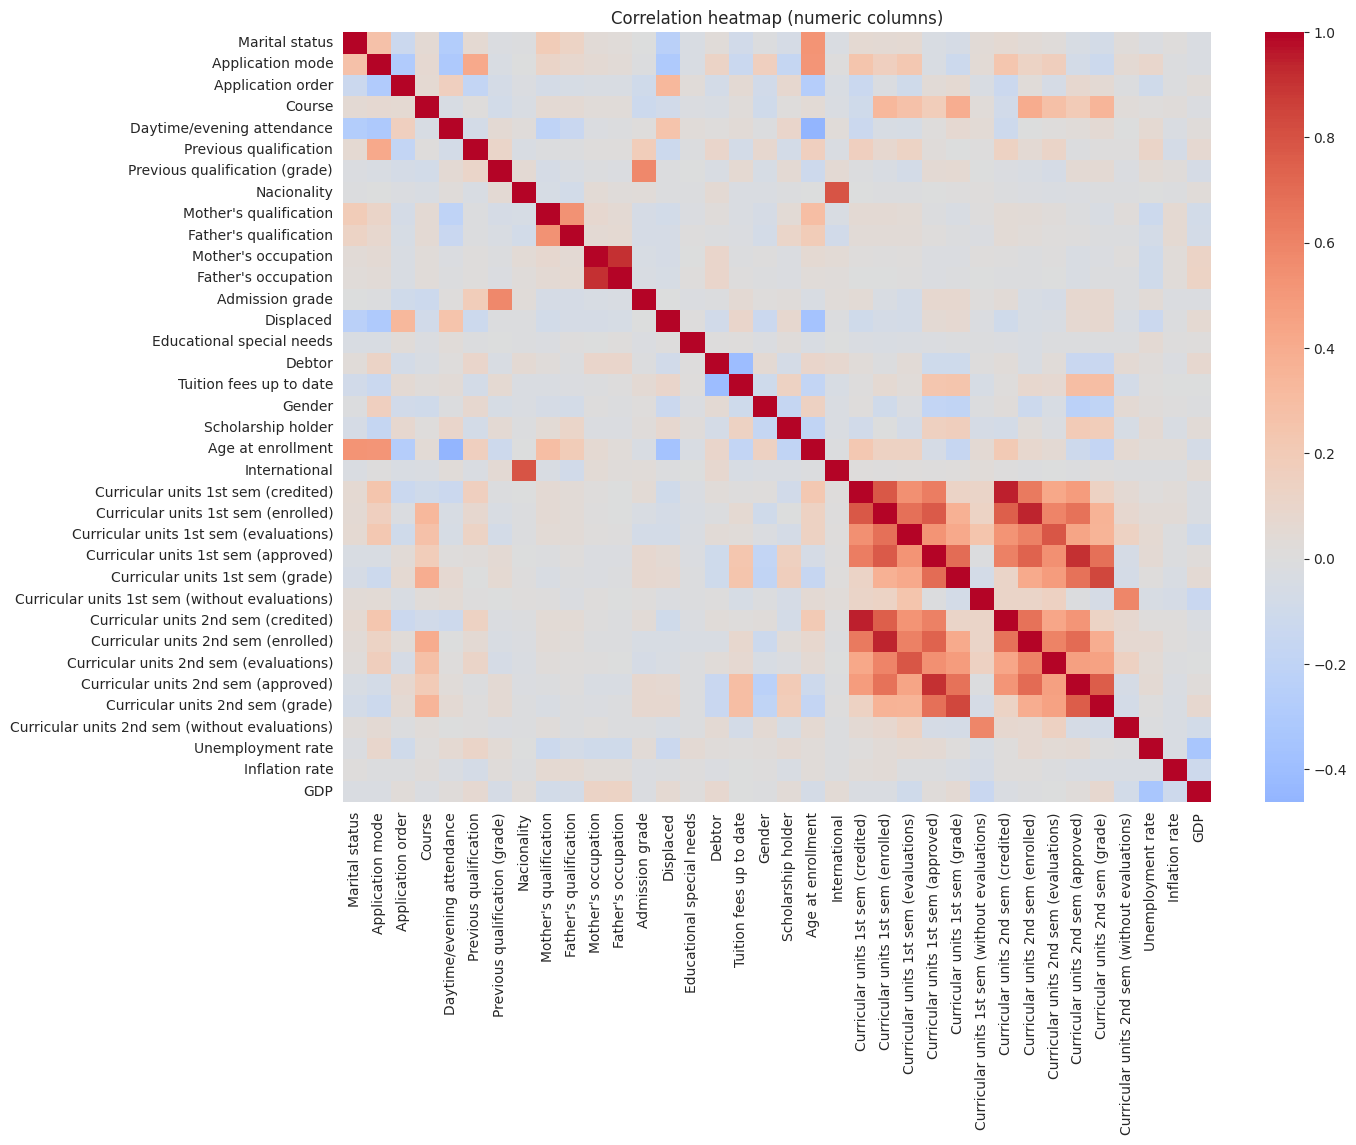

In [10]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Correlation heatmap (numeric columns)')
plt.show()

## 2. Data Cleaning
Missing-value imputers are defined here even though this dataset happens to be complete —
this keeps the pipeline robust to a different pull of the same data.

In [11]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

### 2.3 Outlier Detection (IQR rule) — investigate, don't blindly drop

In [12]:
def iqr_outliers(series):
    q1, q3 = series.quantile([.25, .75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lo) | (series > hi)).sum()

for col in ['Admission grade', 'Age at enrollment',
            'Curricular units 1st sem (grade)', 'Unemployment rate']:
    print(col, '->', iqr_outliers(df[col]), 'flagged of', len(df))

Admission grade -> 86 flagged of 4424
Age at enrollment -> 441 flagged of 4424
Curricular units 1st sem (grade) -> 726 flagged of 4424
Unemployment rate -> 0 flagged of 4424


## 3. Feature Engineering

### 3.1 New Features

In [13]:
eps = 1e-6
df['approval_rate_s1'] = df['Curricular units 1st sem (approved)'] / \
                          (df['Curricular units 1st sem (enrolled)'] + eps)
df['approval_rate_s2'] = df['Curricular units 2nd sem (approved)'] / \
                          (df['Curricular units 2nd sem (enrolled)'] + eps)

df['grade_trend'] = df['Curricular units 2nd sem (grade)'] - \
                     df['Curricular units 1st sem (grade)']

df['total_enrolled'] = df['Curricular units 1st sem (enrolled)'] + \
                        df['Curricular units 2nd sem (enrolled)']
df['total_approved'] = df['Curricular units 1st sem (approved)'] + \
                        df['Curricular units 2nd sem (approved)']

df['zero_approval_flag'] = ((df['Curricular units 1st sem (approved)'] == 0) |
                             (df['Curricular units 2nd sem (approved)'] == 0)).astype(int)

df['age_bucket'] = pd.cut(df['Age at enrollment'],
                           bins=[0, 20, 25, 35, 100],
                           labels=['18-20', '21-25', '26-35', '36+'])

df['parent_edu_max'] = df[["Mother's qualification", "Father's qualification"]].max(axis=1)

df[['approval_rate_s1', 'approval_rate_s2', 'grade_trend',
    'zero_approval_flag', 'age_bucket', 'parent_edu_max']].head()

,approval_rate_s1,approval_rate_s2,grade_trend,zero_approval_flag,age_bucket,parent_edu_max
0,0.000000,0.000000,0.000000,1,18-20,19
1,1.000000,1.000000,-0.333333,0,18-20,3
2,0.000000,0.000000,0.000000,1,18-20,37
3,1.000000,0.833333,-1.028571,0,18-20,38
4,0.833333,1.000000,0.666667,0,36+,38


### 3.2 Variable Transformation (skew correction, applied on the linear-model branch)

In [14]:
skewed_cols = ['Curricular units 1st sem (credited)',
               'Curricular units 2nd sem (credited)']
df_log = df.copy()
for col in skewed_cols:
    df_log[col + '_log'] = np.log1p(df_log[col])

df_log[[c + '_log' for c in skewed_cols]].describe().round(2)

,Curricular units 1st sem (credited)_log,Curricular units 2nd sem (credited)_log
count,4424.00,4424.00
mean,0.22,0.18
std,0.61,0.54
min,0.00,0.00
25%,0.00,0.00
50%,0.00,0.00
75%,0.00,0.00
max,3.04,3.00


### 3.3 / 3.4 Define Column Groups for Encoding and Scaling

In [15]:
nominal_cols = ['Marital status', 'Application mode', 'Course',
                'Nacionality', "Mother's occupation", "Father's occupation"]

binary_cols = ['Displaced', 'Educational special needs', 'Debtor',
               'Tuition fees up to date', 'Gender', 'Scholarship holder',
               'International', 'Daytime/evening attendance', 'zero_approval_flag']

standard_cols = ['Admission grade', 'Previous qualification (grade)']

robust_cols = ['Curricular units 1st sem (enrolled)', 'Curricular units 2nd sem (enrolled)',
               'Curricular units 1st sem (evaluations)', 'Curricular units 2nd sem (evaluations)',
               'total_enrolled', 'total_approved']

minmax_cols = ['Unemployment rate', 'Inflation rate', 'GDP']

engineered_numeric = ['approval_rate_s1', 'approval_rate_s2', 'grade_trend', 'parent_edu_max']

print('Nominal:', len(nominal_cols), '| Binary:', len(binary_cols),
      '| Standard-scaled:', len(standard_cols), '| Robust-scaled:', len(robust_cols),
      '| MinMax-scaled:', len(minmax_cols), '| Engineered numeric:', len(engineered_numeric))

Nominal: 6 | Binary: 9 | Standard-scaled: 2 | Robust-scaled: 6 | MinMax-scaled: 3 | Engineered numeric: 4


Quick preview of one-hot encoding size before it's folded into the full pipeline:

In [16]:
from sklearn.preprocessing import OneHotEncoder

ohe_preview = OneHotEncoder(handle_unknown='ignore', min_frequency=0.01, sparse_output=False)
encoded_preview = ohe_preview.fit_transform(df[nominal_cols])
print('Encoded shape:', encoded_preview.shape)

Encoded shape: (4424, 57)


### 3.5 Correlation Filtering (drop redundant numeric columns)

In [17]:
corr = df.select_dtypes('number').corr().abs()
high_corr_pairs = [(c1, c2) for c1 in corr.columns for c2 in corr.columns
                   if c1 < c2 and corr.loc[c1, c2] > 0.9]
print('Highly correlated pairs (|r| > 0.9):', len(high_corr_pairs))
for pair in high_corr_pairs:
    print(' ', pair[0], '<->', pair[1])

Highly correlated pairs (|r| > 0.9): 9
  Father's occupation <-> Mother's occupation
  Curricular units 1st sem (credited) <-> Curricular units 2nd sem (credited)
  Curricular units 1st sem (enrolled) <-> Curricular units 2nd sem (enrolled)
  Curricular units 1st sem (enrolled) <-> total_enrolled
  Curricular units 1st sem (approved) <-> Curricular units 2nd sem (approved)
  Curricular units 1st sem (approved) <-> total_approved
  Curricular units 2nd sem (enrolled) <-> total_enrolled
  Curricular units 2nd sem (approved) <-> total_approved
  Curricular units 2nd sem (grade) <-> zero_approval_flag


In [18]:
# Drop one column from each highly correlated pair (keep the more directly interpretable one)
cols_to_drop = ['Curricular units 1st sem (evaluations)', 'Curricular units 2nd sem (evaluations)']
df = df.drop(columns=cols_to_drop)
robust_cols = [c for c in robust_cols if c not in cols_to_drop]

## 4. Assemble the Full Pipeline

Fitting happens only on the training split; the same fitted transformers are then applied to the
test split with `.transform()`, which prevents test-set leakage.

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

X = df.drop(columns=['Target', 'age_bucket'])  # age_bucket kept for reference/EDA only here
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

numeric_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
])

preprocessor = ColumnTransformer([
    ('robust', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', RobustScaler())]), robust_cols),
    ('standard', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), standard_cols),
    ('minmax', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', MinMaxScaler())]), minmax_cols),
    ('engineered', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), engineered_numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=0.01), nominal_cols),
    ('bin', SimpleImputer(strategy='most_frequent'), binary_cols),
], remainder='drop')

pipe = Pipeline([('preprocessing', preprocessor)])

X_train_ready = pipe.fit_transform(X_train)
X_test_ready = pipe.transform(X_test)

print('Train shape:', X_train_ready.shape)
print('Test shape :', X_test_ready.shape)

Train shape: (3539, 79)
Test shape : (885, 79)


**Week -3**

# Model Implementation

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

full_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', rf_model),
])

full_pipeline.fit(X_train, y_train)
print('Model trained on', X_train.shape[0], 'students.')

Model trained on 3539 students.


              precision    recall  f1-score   support

     Dropout       0.81      0.74      0.78       284
    Enrolled       0.52      0.47      0.49       159
    Graduate       0.82      0.90      0.86       442

    accuracy                           0.77       885
   macro avg       0.72      0.70      0.71       885
weighted avg       0.76      0.77      0.77       885



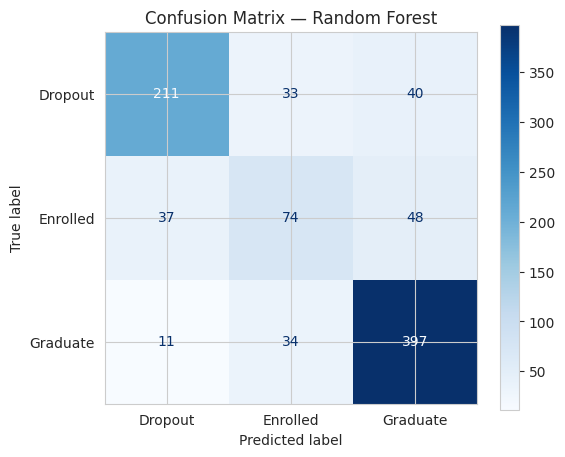

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = full_pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, labels=full_pipeline.classes_, ax=ax, cmap='Blues'
)
plt.title('Confusion Matrix — Random Forest')
plt.show()

### Sanity check: does the model beat a naive baseline?

A model is only useful if it outperforms the simplest possible guess — always predicting
the majority class (`Graduate`). This quick assertion acts as a regression guardrail:
if a later change makes the model worse than guessing, this cell will fail loudly.

In [23]:
from sklearn.metrics import f1_score

majority_class = y_train.value_counts().idxmax()
baseline_preds = [majority_class] * len(y_test)
baseline_f1 = f1_score(y_test, baseline_preds, average='macro')
model_f1 = f1_score(y_test, y_pred, average='macro')

print(f'Majority-class baseline macro F1: {baseline_f1:.3f}')
print(f'Random Forest macro F1:           {model_f1:.3f}')
assert model_f1 > baseline_f1, 'Model should outperform the majority-class baseline'
print('Passed: model outperforms the naive baseline.')

Majority-class baseline macro F1: 0.222
Random Forest macro F1:           0.709
Passed: model outperforms the naive baseline.


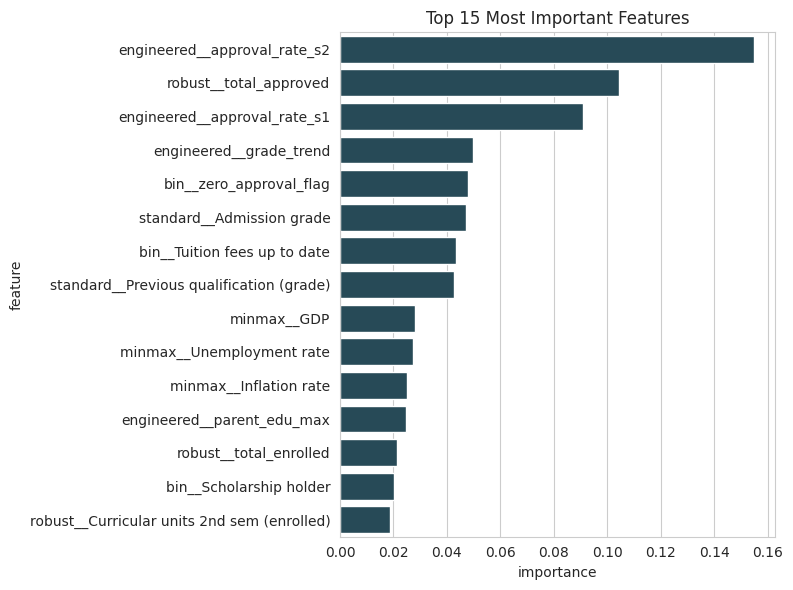

,feature,importance
10,engineered__approval_rate_s2,0.154975
3,robust__total_approved,0.104296
9,engineered__approval_rate_s1,0.090726
11,engineered__grade_trend,0.049657
78,bin__zero_approval_flag,0.047768
4,standard__Admission grade,0.047171
73,bin__Tuition fees up to date,0.043273
5,standard__Previous qualification (grade),0.042592
8,minmax__GDP,0.028003
6,minmax__Unemployment rate,0.027129


In [24]:
importances = full_pipeline.named_steps['classifier'].feature_importances_
feature_names = full_pipeline.named_steps['preprocessing'].get_feature_names_out()

importance_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .head(15)
)

plt.figure(figsize=(8, 6))
sns.barplot(x='importance', y='feature', data=importance_df, color='#1F4E5F')
plt.title('Top 15 Most Important Features')
plt.tight_layout()
plt.show()

importance_df

## Hyperparameter tuning

In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__n_estimators': [200, 300],
    'classifier__max_depth': [None, 20],
    'classifier__min_samples_leaf': [1, 2],
}

search = GridSearchCV(
    full_pipeline,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
)
search.fit(X_train, y_train)

print('Best params:', search.best_params_)
print('Best CV macro F1:', round(search.best_score_, 3))

best_pipeline = search.best_estimator_

Best params: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 300}
Best CV macro F1: 0.724


In [26]:
import joblib

joblib.dump(best_pipeline, 'rf_pipeline_v1.joblib')
print('Saved: rf_pipeline_v1.joblib')

Saved: rf_pipeline_v1.joblib
